<a href="https://colab.research.google.com/github/trevorlillywhite/HW5_ST554_Trevor_Lillywhite/blob/main/HW_5_ST_554_Trevor_Lillywhite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5 - ST 554

#### Author: Trevor Lillywhite
#### Due date: March 3, 2026

## Part I: Concepts

### 1) "Five V's of Big Data"

**Instructions:** We discussed the “Five V’s of Big Data”. Give an example of a place where you’ve encountered big
data or a topic you are interested in where big data would arise. Specifically address the five V’s for
the example and whether/how they apply to your example.

**Response:** Concepts for future military operations involve many different networked sensors to understand the environment, the adversary, and the status of friendly forces. This includes satellite/aerial imagery, radar stations, acoustic arrays, fixed and mobile environmental sensors, biometric sensors, and many more. The massive amount of data generated by these sources would certainly be considered "big data," as it clearly meets each of the "Five V's."

+ **Volume:** Each sensor type has the potential to generate massive amounts of data over time, quickly exceeding our ability to handle this data using traditional computation methods. Imagery/video feeds, in particular, will take up an enormous amount of storage space/memory. Even sensors that output simple numerical data streams can quickly scale to unmanageable volumes based on the update frequency and vast number of sensors deployed across the theater of operations.

+ **Variety:** As mentioned earlier, there will be a huge number of different data sources each with distinct data formats. Even sensors belonging to the same family (e.g., acoustic sensors) may have very different output formats depending on the sensor's design, purpose, manufacturer, edge processing capabilities, etc.

+ **Velocity:** Most of these sensors will measure data in real time (or near-real time), though many won't have the ability to continuously stream live data over a network. The velocity of data will vary, but the only "constant" will be change (both in the data available to analysts/decision makers, and in the actual real-world conditions being characterized). This velocity will pose challenges in analyzing the data at the "speed of need" but will further complicate decision making processes if too many changes are shown too fast. Cognitive overload is expected to be problematic, contributing to the "fog of war" from an overabundance of constantly changing data instead of the tradiational lack of data.

+ **Variability:** All sensors have bias and error due to physical sources of noise or technical limitations restricting their capability (e.g., precision, accuracy, resolution, etc.). Sensors fielded in the same area measuring the same thing may output different values due to this noise or even due to changing conditions. Spatiotemporal tagging will be critical to tease out whether data variability is likely due to natural fluctuations or due to changing conditions.   

+ **Value:** There are numerous quotes about the advantage that knowledge has in war. The reason is self evident. Battlefield awareness is critical to ensuring your resources are optimally allocated to defend your strategic postions and gain an advantage over the adversary. Much of the data gathered will have a very low value density, but properly assembled and interpreted, it could save thousands of lives. On the converse, an excess of raw data that has not been transformed to actionable information may be paralyzing.


### 2) CRUD

**Instructions:** Read about the database we’ll use below (part IV). Give an example for each letter in the CRUD acronym in the context of this database.

**Response:**

+ **Create:** When Jeff Knecht created the SQLite version of the database, he had to create new tables corresponding to the MySQL data, and then populate those tables with the corresponding information.
+ **Read:** When Jeff or others want to query the data for browsing or analysis, they need to read what was previously entered into the associated tables, potentially using `JOIN` functions to view related data from multiple tables simultaneously.
+ **Update:** Each year, another season of baseball adds to the wealth of stats that can be added to the database. Jeff hasn't kept up with this recently, but notionally, he could update the database with new rows for the new data generated each year.
+ **Delete:** If an entry is created or updated erroneously (e.g., duplicate rows entered), there's a chance that the data should be deleted instead of simply updated. There may be other situations where an entry should be deleted even if there wasn't a data entry mistake (e.g., if a player is caught using performance enhancing drugs and consequently has their records or special statuses expunged).

### 3) `HAVING` Clause

**Instructions:** What is the purpose of the `HAVING` clause when writing SQL code? (Recall the sqlitetutorial.net tutorial on the `SELECT` statement.)

**Response:** The `HAVING` clause effectively filters the data according the the expression that follows the `HAVING` clause. For example, consider the following query:
```
SELECT col1, col2
FROM table1
HAVING value1 > 10
```
Here, two columns (`col1` and `col1`) are selected from `table1`. However, the rows will only be returned if the value of `value1` is > 10. The expression "`value1 > 10`" is used to filter the full set of rows in `table1`.



## Part II: Simulation of a Sampling Distribution

### 4) Sampling Distribution of SLR Model Sample Slope

**Instructions:** We looked at using simulation to investigate the sampling distribution of $\hat{p}$ in the notes. We'll now look at the sampling distribution of the sample slope from an SLR model using simulation.

+ Recall we assume the following model for SLR:
$Y_i = β_0 + β_1x_i + E_i$
where the $E_i$ are assumed to be indendent and identically distributed from a Normal distribution
with mean 0 and variance $σ^2$. Let's assume $σ^2 = 1$ for simplicity.
+ We can generate data from this model by assuming values for $β_0$, $β_1$, and $n$, along with a sequence of $x$ values via the following code:
>[`code omitted here for brevity`]
+ Now we can use `sklearn` to obtain the estimate for the slope (and save that value) as we did earlier in the course.
+ Repeat the above process 5000 times. To be specific
    - Generate the y values using the code with `rng.standard_normal()`
    - Find the 'best' slope via `sklearn`
    - Save that slope in some object

_Approach:_ We will first replicate the code shown in the assignment instructions to verify its functionality. After we have our sample data, we will verify functionality of our `sklearn` regression. We will then turn that code into a function that returns the simulated data points including randomized noise (fixed by a random seed for repeatability). Then we will use `sklearn` to regress the 'best' slope for each simulation in a specified sample size (here, 5000). Finally, we can use that object with the returned set of sample slopes for further analysis.

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.  0.  1.  2.  3.  4.  5.  6.
  7.  8.  9. 10.  0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


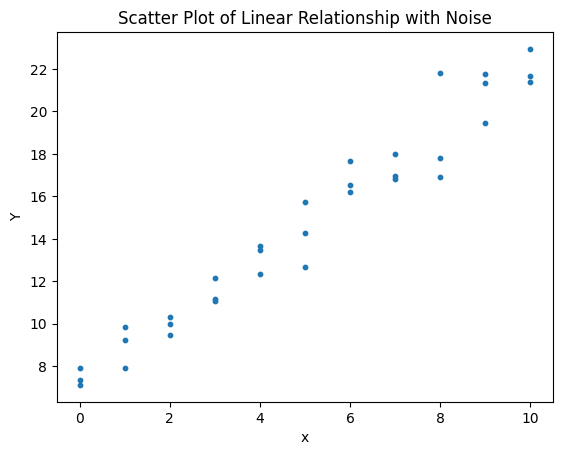

In [1]:
# Replicate code to determine one sample of data points

#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
print(x)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y, s=10)
plt.title('Scatter Plot of Linear Relationship with Noise')
plt.xlabel('x')
plt.ylabel('Y')
plt.show()

In [2]:
# Check shape of x, y
print(x.shape)
print(y.shape)

(33,)
(33,)


In [3]:
# Determine sample slope using sklearn
# Import relevant module
import sklearn
# Instantiate linear regression model as an object
lin_reg = sklearn.linear_model.LinearRegression()
# Fit model on data
lin_reg.fit(x.reshape(-1,1), y.reshape(-1,1))
# Determine fitted parameters (coefficient (AKA slope) and intercept)
slope = lin_reg.coef_
intercept = lin_reg.intercept_
print('Fitted Slope: ', slope[0,0].round(4))
print('Fitted Intercept: ', intercept[0].round(4))

Fitted Slope:  1.4745
Fitted Intercept:  7.259


The fitted slope and intercept are very close to the true values (1.5 and 7).

Now that we have demonstrated the ability to calculate the slope once, we will turn this into a function.

In [4]:
# Wrap code into a function to return a set of sample slopes

def get_slopes(n_samples, beta_0_input = 7, beta_1_input = 1.5):
    '''
    This function takes given value of beta_0 (default: 7) and
    beta_1 (default: 1.5) and generates random samples around the line
    Y_i = beta_0 + beta_1*x_i + E_i where E_i is determined by
    randomly sampling a unit standard normal distribution.
    The user specifies the number of samples to repeat.
    The function outputs an array of the sample slopes for each sample.
    '''
    # Set random seed
    seed = 32
    rng = default_rng(seed)
    # Get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    n = len(x)

    # Initialize empty array for each sample's fitted slope
    slope_set = np.zeros(n_samples)
    # Iteratively create y-values for each sample and fit a slope using SLR
    for i in range(n_samples):
        # Create the 'responses' modeled from the line plus a random deviation
        y = beta_0 + beta_1*x + rng.standard_normal(n)
        # Instantiate linear regression model as an object
        reg = sklearn.linear_model.LinearRegression()
        # Fit model on data
        reg.fit(x.reshape(-1,1), y.reshape(-1,1))
        # Determine fitted slope (the first and only SLR coefficient)
        slope_set[i] = reg.coef_[0,0]
    return slope_set

In [5]:
# Generate 5000 independent sample slopes
slopes = get_slopes(5000)
# Print mean to check functionality
slopes.mean()

np.float64(1.5001065405182452)

**Instructions:**
+ We can use the many values of the sample slope as an approximation to the sampling distribution of the sample slope! Create a histogram of the sample slope values you found.

_Approach:_ We will convert the `numpy` array to a pandas series. Then, we can use the built-in histogram function quite conveniently.

In [6]:
# Import relevant module
import pandas as pd
# Convert results to pandas DataFrame
slopes = pd.DataFrame(slopes)
slopes.columns = ['fitted_slope']
slopes

,fitted_slope
0,1.474506
1,1.452806
2,1.533154
3,1.472032
4,1.441669
...,...
4995,1.470190
4996,1.461474
4997,1.461199
4998,1.502327


Text(0, 0.5, 'Frequency')

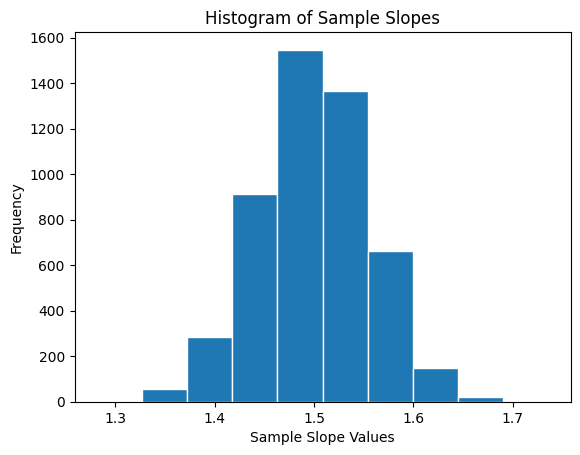

In [7]:
# Create histogram
slopes.hist(edgecolor='white', grid=False)
plt.title('Histogram of Sample Slopes')
plt.xlabel('Sample Slope Values')
plt.ylabel('Frequency')

The histogram shows an approximately normal distribution, as expected, with a sample mean somewhere around 1.5.

**Instructions:**
+ Use your sampling distribution to approximate the probability of observing a sample slope larger than 1.65. This can be done by looking at the proportion of simulated values larger than 1.65.

_Approach:_ First, we will use the `describe()` method with custom quantile selections to gain numerical insights about the sample distribution. Then, we will subset the data and measure the length of the new DataFrame with sample slopes larger than 1.65. This length will be dividied by the total number of samples (5000) to determine the proportion of simulated slopes larger than 1.65. Finally, we will compare this result with the insights we previously gained using the `describe()` method to validate the reasonability of our results.

In [8]:
# Describe dataset using relevant percentiles
pct = [0.9, 0.95, 0.99, 0.999]
slopes.describe(percentiles=pct)

,fitted_slope
count,5000.000000
mean,1.500107
std,0.055322
min,1.281509
50%,1.500038
90%,1.570923
95%,1.590980
99%,1.626417
99.9%,1.679030
max,1.735569


Based on these results, we should expect our calculated proportion to be somewhere between the 99th and 99.9th percentiles. The subsetted DataFrame should include between 5 and 50 samples.

In [9]:
slopes_high = slopes[slopes.fitted_slope > 1.65]
slopes_high.describe()

,fitted_slope
count,19.000000
mean,1.672616
std,0.023501
min,1.650052
25%,1.656088
50%,1.665444
75%,1.682093
max,1.735569


There are 19 fitted slopes with values > 1.65. The numeric sumamries confirm that only the desired slopes were included in the subsetted DataFrame.

In [10]:
# Determine proportion of slopes with values > 1.65
proportion = len(slopes_high)/len(slopes)
print('Proportion of sample slopes > 1.65 (decimal): ', proportion)

Proportion of sample slopes > 1.65 (decimal):  0.0038


The probability of observing a sample slope > 1.65 is approximately 0.0038.

This value aligns with our initial bounding analysis. The number of sample slopes in the range of interest was 19 (predicted to be between 5 and 50), and the percentile corresponding to a sample slope of 1.65 is between 99% and 99.9% (because the actual proportion is 0.0038, or 0.38%, which corresponds to the top 99.62% of the sample set).

**Instructions:**
+ Give an interpretation of this value and why it might be important for us in relation to a hypothesis test.

**Response:** If the simulation was repeated an extremely large number of times, we would expect that approximately 0.38% of the sample slopes would be above a value of 1.65. There is some error in this value because the statistic was estimated from a finite sample size.

In hypothesis testing, we would set a null hypothesis and an alternative hypothesis. If we set a null hypothesis that the true slope is 1.5 and an alternative hypothesis that the true slope is greater than 1.5, we would need to conduct a number of tests to determine if we have enough statistical evidence to reject the null hypothesis. Let's say the alternative hypothesis is that the true slope is 1.65. The simulations performed above show that, if the null hypothesis is true, we would only reach a value of > 1.65 a very small proportion of the time. As long as our alpha value (Type I Error, or false positive probability) is > 1%, we would be able to clearly distinguish a mean sample slope of 1.65 from the null hypothesis. With an alpha value of 0.05 (which is a common selection), the mean sample slope would only be within the one-sided 95% confidence interval of the null hypothesis if it was below 1.59. Any greater value would lead to a rejection of the null hypothesis in favor of the alternative hypothesis.

## Part III: Big Data Examples & Rare Events

### 5) Bias in ML Models

**Instructions:**
Consider this article about bias in machine learning models: https://international-review.icrc.org/articles/biases-machine-learning-big-data-analytics-ihl-implications-913
+ Pick an example in the article and briefly outline the issue around the data used to fit the model.

**Response:** The article mentioned an example of implicit bias where an automated resume screening system used by Amazon was shown to disfavorably rank women whose resumes indicated their presumed gender (e.g., "women's chess club captain"). This resulted from training data that used gender-specific language and drew a link between women and a lower hiring favorability. The precise details leading to the bias are unclear from the article, but it is possible that the model identified a spurrious correlation or even that it uncovered human bias that was actually present in tradiational hiring activities. Regardless, the bias was carried forward and likely negatively (and unjustly) impacted applicants before it was discovered.  

**Instructions:**
+ Describe how we might augment the data or otherwise account for the bias in that situation.

**Response:** The model should be checked for biases during initial training and fine tuning, and even after deployment (especially if the model is not static, such as if it adapts over time through reinforcement learning or is periodically augmented with newer training data). Once a bias is uncovered, the developers should investigate the cause to see if it can be remediated. There are several options to prevent or correct biases, as long as they are discovered and adequately characterized.

+ If the full dataset contained a balanced/representative population, but the model still produced a bias, the development team can check to see if the training and validation/test sets were properly split (e.g., were randomization and stratification properly applied?).
+ If portions of a population weren't adequately represented but data is available, more data can be mixed into the training (and validation/test) set. For Amazon, they could search for additional resumes that weren't included or seek resume sources from similar companies.
+ If sufficient data is not available to represent some portions of a population, data for the over-reprsented portion can be intentionally under-sampled to restore balance, if the overall dataset is big enough. Otherwise, synthetic data for under-represented portions of the population can be made (if practical) through techniques like Synthetic Minority Oversampling Technique (SMOTE). It would be difficult to generate entirely new synthetic resumes in this case, but other successful resumes could be modified to create examples where the implied gender is neutrally or positively favored (to counter-balance the model's internal parameters).
+ Specific to this case, since the cause of the bias can be identified, another data processing layer can be added to neutralize bias-inducing language before the resume is analyzed by the biased model. For example, an LLM can remove or modify words hinting at a person's gender or race (though this would require oversight to ensure additional biases are not being added). If this technique is used, the pre-processing algorithm should be widely tested, potentially on the entire training/test set before analytical model development.

### 6) Big Data Usage in Earth Sciences

**Instructions:**
Consider this article about big data usage in the Earth Sciences: https://www.science.org/doi/10.1126/science.adh9607
+ Choose one of the three major areas the paper discusses. Summarize the use of big data there. Are there any biases or other missing data that might affect results? (I know this is likely difficult as most of us aren’t experts in Earth science - just do your best - my goal is to try to get us to always ask questions about the data collected and used for a study!)

**Response:**

### 7) Rare Events

**Instructions:**
Read through this short article: https://allendowney.substack.com/p/superbolts?utm_source=substack&utm_medium=email
+ Mostly I just want you to read this article to understand some ways in which rare events, and statisticians, play a role in different places. To have something to put here, can you think of another variable or scenario where understanding rare events is important?

**Response:**

## Part IV: Querying a Database

**Instructions:** There is a database file on the assignment link called Lahman.db that is an sqlite database downloaded from here. This database has information on Major League Baseball.

https://github.com/jknecht/baseball-archive-sqlite

### 8)
**Instructions:** Connect to the database (probably by uploading to Colab) and then look at all of the tables in the database (use `read_sql()` from pandas to have this returned as a data frame).

_Approach:_

### 9)
**Instructions:** Write an SQL query using `pd.read_sql()` that returns all the teams that played in the year 2015 with all of the corresponding columns from the `Teams` table.

_Approach:_

### 10)
**Instructions:** Write an SQL query using `pd.read_sql()` that returns all of the players in the hall of fame, the year they were voted into the hall of fame, and their category - see the `HallOfFame` table, the inducted variable is important here.

_Approach:_

### 11)
**Instructions:** Write an SQL query using `pd.read_sql()` that return all unique managers of the Pittsburgh Pirates (`teamID` of `PIT`) and only that information from the `Managers` table. Hint: Check out `SELECT
DISTINCT`

_Approach:_

### 12)
**Instructions:** Use SQL code and the `HallOfFame` and `Managers` tables to return all of the `playerIDs` for the people that managed for a team that were inducted into the hall of fame. Also, programmatically report the number of such people - this can be done in `pandas` after returning the data from the call to `pd.read_sql()`.

_Approach:_

### 13)
**Instructions:** Now use the same two tables (`HallOfFame` and `Managers`) and an SQL query to return every season managed by each manager that made it to the hall of fame (so do this with an SQL join, not via `pd.merge()`). You should return the `playerID` (manager ID), `G`, `W`, and `L` columns from the `Managers` table.

Second, determine the overall win/loss records (sum of wins and sum of losses) for each of these hall of fame managers. Third, create a new variable that is the win/loss percentage (`W`/(`W`+`L`)). Lastly, sort the resulting data by the win/loss percentage variable (from largest to smallest). The last three parts can be done in pandas with the returned data or you can do it via SQL in your call to `pd.read_sql()`.

_Approach:_